In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot

plot_dir = './plots'

In [13]:
config1 = dict(
    # input_filename = 'hessian120k16k_eigs.npz',
    input_filename = 'hessian120k16k_eigs_half.npz',  # half powers of 2
    deg_m = 3,
    effective_n = 80_000,
    xlim = (0, 0.8),
    ylim = (19, 19, 7),
    nbins = (80, 200),
    label_mode = 'pow-dec',
    save_filename = 'hessian120k16k',
)

# Homogeneous version of config1. It has one bulk
# config2 = dict(
#     input_filename = 'hessian120k16khomo_eigs.npz',
#     deg_m = 3,
#     effective_n = 80_000,
#     xlim = (0, 0.8),
#     ylim = (19, 19, 7),
#     nbins = (80, 200),
#     label_mode = 'pow-int',
#     save_filename = 'hessian120k16khomo',
# )

config3 = dict(
    input_filename = 'hessian2100k32k_eigs.npz',
    deg_m = 4,
    effective_n = 25_000,
    xlim = (-0.03, 0.6),
    ylim = (30, 30, 15),
    nbins = (80, 1000),
    label_mode = 'pow-int',
    save_filename = 'hessian2100k32k',
)

# -------

# config = config1
# config = config2
config = config3

In [14]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

for i in range(sizes.size):
    print(f'{i:>2d}: {sizes[i]:>6d}')

 0:   1000
 1:   2000
 2:   4000
 3:   8000
 4:  16000
 5:  32000


fit residual max  : 1.0231e-03
fit residual 99.9%: 2.8822e-04

Coefficients (real)
+0.08466241 -0.00144732 -0.00027845 +0.00000127 +0.00000000 
-0.91533758 +0.12955041 +0.00890918 -0.00001879 -0.00000015 
+0.00000000 -0.91533718 -0.05125825 -0.00015322 +0.00000176 

Coefficients (imag) norm: 0.0000e+00

Stieltjes sanity check: OK

Support:
[(0.024332428104030555, 0.04955977887773382), (0.055776073771732625, 0.06303688051661593), (0.11774205360928447, 0.21729102260182212)]

Atoms:
[]


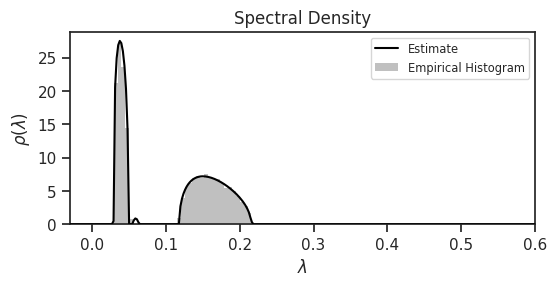

In [15]:
start_idx = 0
ratio = sizes[start_idx] / config['effective_n']
af = AlgebraicForm(eigs[start_idx], ratio=ratio, support=None, delta=1e-5)

deg_m = config['deg_m']
deg_z = 2

coeffs = af.fit(
    deg_m, deg_z, reg=0, normalize=True, triangular=None,
    mu='auto', mu_reg=0, verbose=True)

print('\nSupport:')
est_supp = af.support()
print(est_supp)

print('\nAtoms:')
print(af.atoms())

x_min, x_max = config['xlim']
x = numpy.linspace(x_min, x_max, 300)
rho0 = af.density(x, plot=True, latex=False)

success rate per t: [1. 1. 1. 1. 1. 1.]


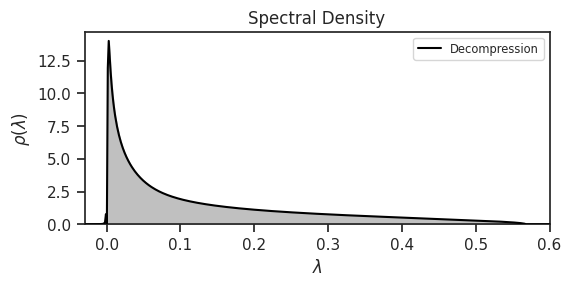

In [16]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]
x = numpy.linspace(x_min, x_max, 500)

newton_opt = dict(
    dt_max=0.02,
)

rho, x = af.deform(
    fd_sizes, x=x, method='moc', min_n_times=0,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0, verbose=True, plot=True, latex=False)

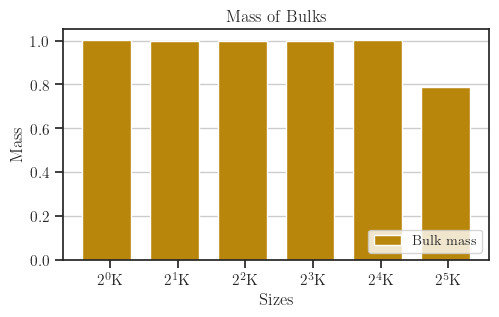

In [17]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-flow.pdf".


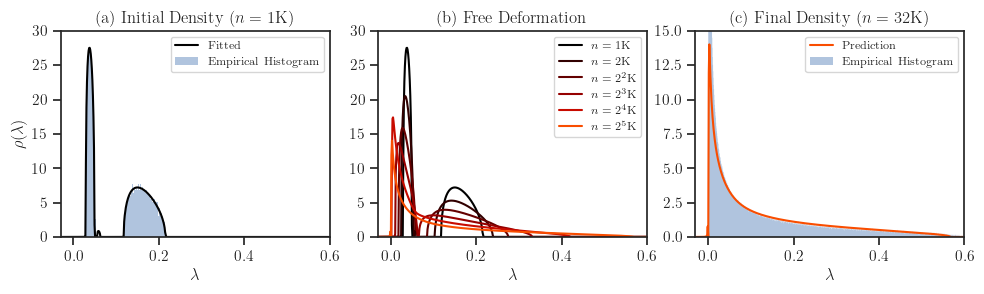

In [18]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], xlim=config['xlim'],
          ylim=config['ylim'], sharey=False,
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=config['nbins'],
          label_mode=config['label_mode'],
          save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=True)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/hessian2100k32k-ridge.pdf".


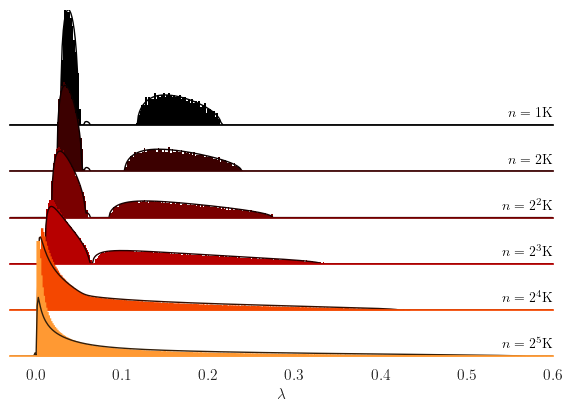

In [19]:
ridgeplot(fd_sizes, x, rho, eigs, text_side='right', hspace=-0.6, scaley=False,
          xlim=config['xlim'],
          label_mode=config['label_mode'],
          save=False,
          # save=join(plot_dir, config['save_filename'] + '-ridge.pdf'),
          latex=True)